# PCA and SVD Recovery

In [1]:
import numpy as np
from matplotlib.pyplot import subplots
from pathlib import Path
import sys
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / "src"))
from dynamics import *
from simulations import *
from dimensionality_reduction import *
from metrics import reconstruction_error
rng = np.random.default_rng(0)

# Simulating Neural Population

In [2]:
theta = np.pi/4
r = 0.98
x0 = np.array([1, 1])
T = 100
noise_std = 0.1
A = damped_rotation_matrix(theta, r)
X = simulate_linear_system(A, x0, T, noise_std, rng=rng)

n_neurons = 100
latent_dim = x0.shape[0]
C = generate_observation_matrix(n_neurons, latent_dim, scale=1.0, rng=rng)
Y = X @ C.T
Y = add_observation_noise(Y, noise_std)

We begin by generating a simulated neural population using the dynamical system generated in the previous notebook. The latent state evolves according to a damped rotation model, but unlike the previous notebook, we have introduced process noise, small random perturbations that influence the hidden dynamics at each time step. The resulting latent trajectory is then projected into the activity of 100 neurons through a randomly generated observation matrix, after which observation noise is added to simulate noisy neural recordings. 

## True vs. PCA-Recovered Latent Trajectory

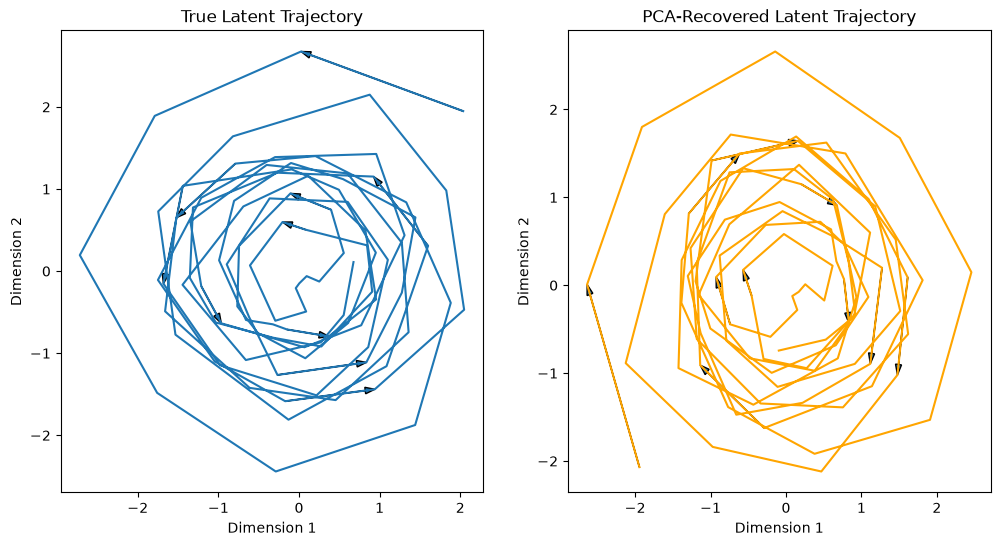

In [3]:
# Compute PCA
n_components = 2
Z_pca, pca_model = run_pca(Y, n_components)

# Standardize true and PCA-recovered trajectories for visual comparison
X_norm = X / np.std(X, axis=0)
Z_norm = Z_pca / np.std(Z_pca, axis=0)

x1, x2 = X_norm[:, 0], X_norm[:, 1]
z1, z2 = Z_norm[:, 0], Z_norm[:, 1]

fig, ax = subplots(nrows=1, ncols=2, figsize=(12, 6))
t = np.arange(len(x1))

# Plot True Latent Trajectory
ax[0].plot(x1, x2, label="True")
for i in range(0, len(x1) - 1, 10):
    ax[0].arrow(
        x1[i], x2[i],
        x1[i+1] - x1[i],
        x2[i+1] - x2[i],
        head_width=0.08,
        length_includes_head=True
    )
ax[0].set_title("True Latent Trajectory")
ax[0].set_xlabel("Dimension 1")
ax[0].set_ylabel("Dimension 2")

# Plot Recovered Latent Trajectory 
ax[1].plot(z1, z2, c='orange', label="Recovered")
for i in range(0, len(z1) - 1, 10):
    ax[1].arrow(
        z1[i], z2[i],
        z1[i+1] - z1[i],
        z2[i+1] - z2[i],
        head_width=0.08,
        length_includes_head=True
    )
ax[1].set_title("PCA-Recovered Latent Trajectory")
ax[1].set_xlabel("Dimension 1")
ax[1].set_ylabel("Dimension 2");

We attempt to recover the original latent structure using principle component analysis (PCA). First, PCA centers the neural activity data by subtracting the mean activity of each neuron. This is done to ensure analysis focuses on covariance patterns instead of baseline activity. Next, PCA computes a low-dimensional representation of the centered neural activity by identifying orthogonal directions that explain the greatest variance. PCA was run using scikit-learn, so this is accomplished by calculating the singular value decomposition (SVD) of the centered data matrix. Since simulated neural activity was generated from two latent variables, we choose to project the data onto the first two principal components. This produces a two-dimensional representation Z which approximates the underlying latent dynamics using only the observed neural activity. Lastly, we standardize both the true and PCA-recovered latent trajectories to remove arbitrary differences in scale. This will allow their geometric structure to be compared visually.

As shown in the two figures, the PCA-recovered trajectory is not identical to the true trajectory. However, it preserves the dominant geometric structure of the underlying dynamics. Both trajectories exhibit similar damped spiral behaviors and converge toward the origin. This indicates that PCA successfully recovered the low-dimensional latent manifold from the high-dimensional neural activity. However, 
the arrows show that the trajectories rotate in opposite directions suggesting that the recovered coordinates are reflected relative to the true coordinates. Additionally, there are slight differences in the trajectories. This is expected since PCA recovers the latent subspace only up to transformations such as rotation, reflection, and scaling. There is also both process and observation noise included in the simulated data.

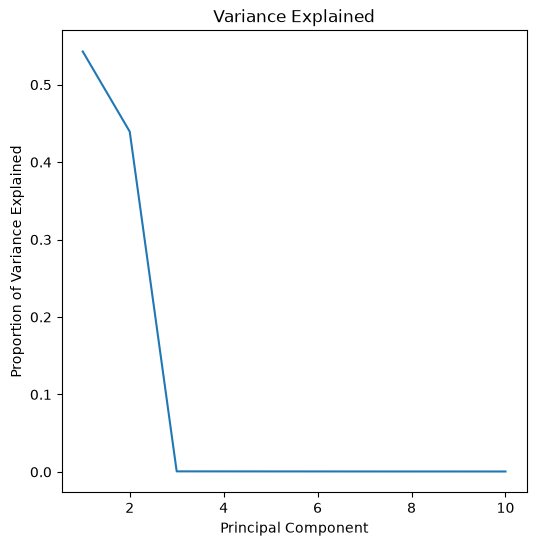

In [4]:
# Compute SVD
U, S, Vt, mean = run_svd(Y)

# Compute variance explained
variance_explained, cumulative_variance = compute_variance_explained(S)
components = np.arange(1, len(variance_explained) + 1)
k=10

# Plot variance explained for first 10 principal components
fig, ax = subplots(nrows=1, ncols=1, figsize=(6, 6))
ax.plot(components[:k], variance_explained[:k])
ax.set_title("Variance Explained")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Proportion of Variance Explained");

As the plot shows, the variance explained by each principal component is consistent with the simulated data being generated from a two-dimensional latent dynamical system. The first two principal components represent almost all of the variance in the neural population activity. The remaining components all together contribute a negligible proportion of variance. This indicates that the 100 by 100 neural activity lie close to a two-dimensional subspace. This is expected from the underlying generative model.

## True vs Reconstructed Neural Activity

MSE: 0.009661


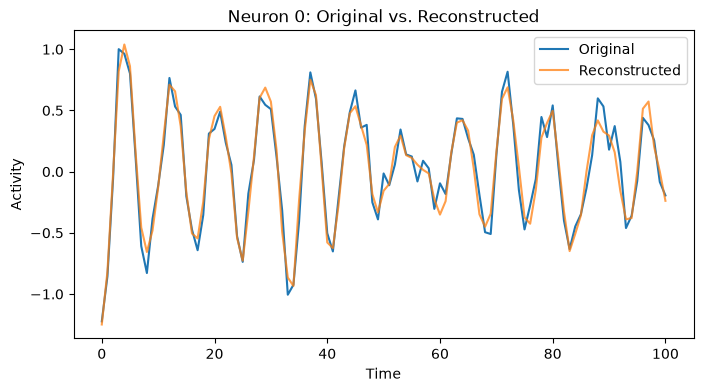

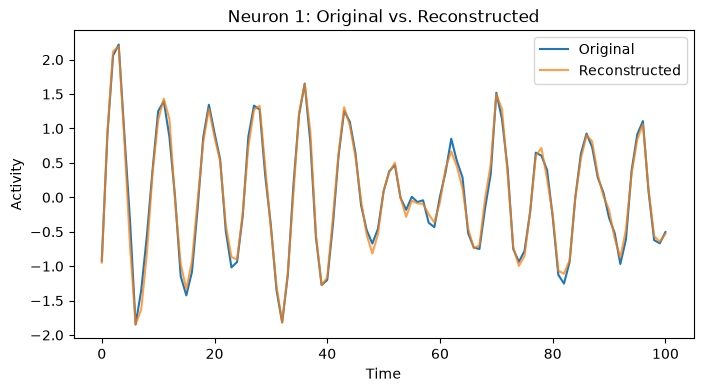

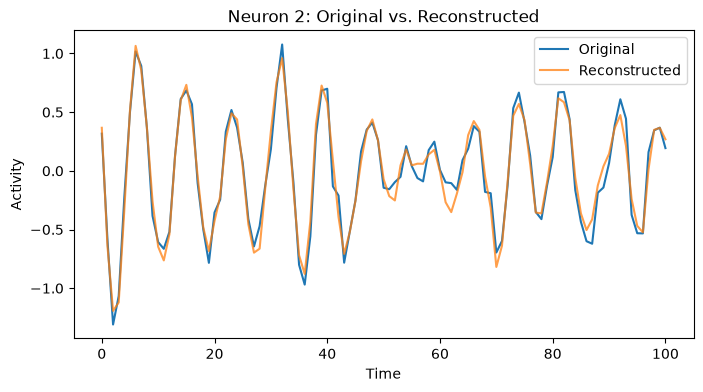

In [5]:
# Reconstruct neural activity
Y_hat = reconstruct_from_pca(Z_pca, pca_model)
error = reconstruction_error(Y, Y_hat)

# Plot original vs reconstructed
for neuron_idx in [0, 1, 2]:
    fig, ax = subplots(figsize=(8, 4))

    ax.plot(Y[:, neuron_idx], label="Original")
    ax.plot(Y_hat[:, neuron_idx], alpha=0.75, label="Reconstructed")

    ax.set_title(f"Neuron {neuron_idx}: Original vs. Reconstructed")
    ax.set_xlabel("Time")
    ax.set_ylabel("Activity")
    ax.legend()
print(f"MSE: {error:3f}")

We reconstruct the neural activity by applying the inverse PCA transform to the recovered low-dimensional representation Z. The plots compare the activity of three representative neurons in the original and reconstructed recordings. The reconstructed activity closely matches the original activity across all three neurons, thus showcasing that the neural population lies close to a two-dimensional subspace. Slight deviations are expected because the simulated data includes both process noise in the latent dynamics and observation noise in the neural recordings. This conclusion is further supported by the low reconstruction error (mean squared error = 0.009) which demonstrates that two principal components capture nearly all of the important information present in the simulated neural activity. 